# Tourist Demand Prediction Based on Destination Weather

**Goal:** Investigate whether destination weather conditions — temperature, precipitation, and humidity — can predict international tourist arrivals at the country level.

**Data sources:**
- *Global Weather Repository* — country-level weather snapshots (temperature, precipitation, humidity, and more)
- *Our World in Data* — international tourist arrivals by country and year

**Approach:** Merge the two datasets on country and year, explore relationships through visualisations, then train regression models to assess predictive power.

In [244]:
pip install pandas numpy matplotlib seaborn scikit-learn shap

Note: you may need to restart the kernel to use updated packages.


In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [246]:
weather = pd.read_csv("../data/GlobalWeatherRepository.csv")
tourism = pd.read_csv("../data/international-tourist-trips.csv")

In [247]:
print(weather.head())
print(tourism.head())

       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...                8.4   
1                    66.2  Partly cloudy

In [248]:
print(weather.columns)
print(tourism.columns)

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')
Index(['Entity', 'Code', 'Year', 'Arrivals of tourists from abroad'], dtype='object')


In [249]:
print(weather.describe())

            latitude      longitude  last_updated_epoch  temperature_celsius  \
count  128833.000000  128833.000000        1.288330e+05        128833.000000   
mean       19.201670      21.981068        1.744516e+09            21.442119   
std        24.421259      65.789383        1.653923e+07             9.676936   
min       -41.300000    -175.200000        1.715849e+09           -29.800000   
25%         3.750000      -6.836100        1.730192e+09            16.200000   
50%        17.250000      23.236100        1.744535e+09            24.100000   
75%        40.400000      50.580000        1.758786e+09            28.000000   
max        64.150000     179.220000        1.773211e+09            49.200000   

       temperature_fahrenheit       wind_mph       wind_kph    wind_degree  \
count           128833.000000  128833.000000  128833.000000  128833.000000   
mean                70.597606       8.048181      12.955899     169.035519   
std                 17.418354       7.314118 

In [250]:
print(tourism.head())

    Entity Code  Year  Arrivals of tourists from abroad
0  Albania  ALB  2007                         1062000.0
1  Albania  ALB  2008                         1247000.0
2  Albania  ALB  2009                         1711000.0
3  Albania  ALB  2010                         2191000.0
4  Albania  ALB  2011                         2469000.0


In [251]:
print(weather.info())
print(tourism.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128833 entries, 0 to 128832
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       128833 non-null  object 
 1   location_name                 128833 non-null  object 
 2   latitude                      128833 non-null  float64
 3   longitude                     128833 non-null  float64
 4   timezone                      128833 non-null  object 
 5   last_updated_epoch            128833 non-null  int64  
 6   last_updated                  128833 non-null  object 
 7   temperature_celsius           128833 non-null  float64
 8   temperature_fahrenheit        128833 non-null  float64
 9   condition_text                128833 non-null  object 
 10  wind_mph                      128833 non-null  float64
 11  wind_kph                      128833 non-null  float64
 12  wind_degree                   128833 non-nul

In [252]:
weather = weather[["country", "location_name", "last_updated", "temperature_celsius", "precip_mm", "humidity"]]
weather.head()

,country,location_name,last_updated,temperature_celsius,precip_mm,humidity
0,Afghanistan,Kabul,2024-05-16 13:15,26.6,0.0,24
1,Albania,Tirana,2024-05-16 10:45,19.0,0.1,94
2,Algeria,Algiers,2024-05-16 09:45,23.0,0.0,29
3,Andorra,Andorra La Vella,2024-05-16 10:45,6.3,0.3,61
4,Angola,Luanda,2024-05-16 09:45,26.0,0.0,89


In [253]:
tourism = tourism[[ "Entity", "Year", "Arrivals of tourists from abroad"]]
tourism = tourism.rename(columns = {
    "Entity" : "country",
    "Arrivals of tourists from abroad": "tourists"
})
tourism.head()

,country,Year,tourists
0,Albania,2007,1062000.0
1,Albania,2008,1247000.0
2,Albania,2009,1711000.0
3,Albania,2010,2191000.0
4,Albania,2011,2469000.0


convert time to year

In [254]:
weather["last_updated"] = pd.to_datetime(weather["last_updated"])
weather["year"] = weather["last_updated"].dt.year
weather.head()

,country,location_name,last_updated,temperature_celsius,precip_mm,humidity,year
0,Afghanistan,Kabul,2024-05-16 13:15:00,26.6,0.0,24,2024
1,Albania,Tirana,2024-05-16 10:45:00,19.0,0.1,94,2024
2,Algeria,Algiers,2024-05-16 09:45:00,23.0,0.0,29,2024
3,Andorra,Andorra La Vella,2024-05-16 10:45:00,6.3,0.3,61,2024
4,Angola,Luanda,2024-05-16 09:45:00,26.0,0.0,89,2024


group_by

In [255]:
weather_yearly = weather.groupby(["country", "year"]).agg({
    "temperature_celsius": "mean",
    "precip_mm": "mean",
    "humidity": "mean"
}).reset_index()
weather_yearly.head()

,country,year,temperature_celsius,precip_mm,humidity
0,Afghanistan,2024,22.696943,0.038603,22.497817
1,Afghanistan,2025,19.436164,0.030137,24.328767
2,Afghanistan,2026,5.828986,0.048841,43.971014
3,Albania,2024,25.022271,0.169651,49.532751
4,Albania,2025,18.878082,0.109562,56.556164


Merging Datasets

In [256]:
df = pd.merge(
    tourism, weather_yearly,
    left_on = ["country", "Year"],
    right_on = ["country", "year"],
    how = "inner"
)
df

,country,Year,tourists,year,temperature_celsius,precip_mm,humidity
0,Albania,2024,11483000.0,2024,25.022271,0.169651,49.532751
1,Andorra,2024,4167600.0,2024,14.105677,0.147860,57.388646
2,Antigua and Barbuda,2024,330200.0,2024,27.931858,0.112788,77.429204
3,Argentina,2024,6603877.0,2024,13.177632,0.053289,80.701754
4,Armenia,2024,2208000.0,2024,22.620524,0.059432,34.746725
5,Bahamas,2024,1869133.0,2024,26.919111,0.086578,78.568889
6,Bahrain,2024,6618000.0,2024,32.711790,0.000000,50.668122
7,Barbados,2024,704340.0,2024,28.227193,0.184167,80.390351
8,Belgium,2024,9638000.0,2024,15.645934,0.108549,73.870330
9,Bosnia and Herzegovina,2024,1388775.0,2024,19.579913,0.235808,59.506550


In [257]:
df.drop(columns = ["year"])
df.shape

(56, 7)

## 2. Exploratory Data Analysis

We visualise the merged dataset to understand the distribution of tourist arrivals and its relationship with each weather feature before building any models.

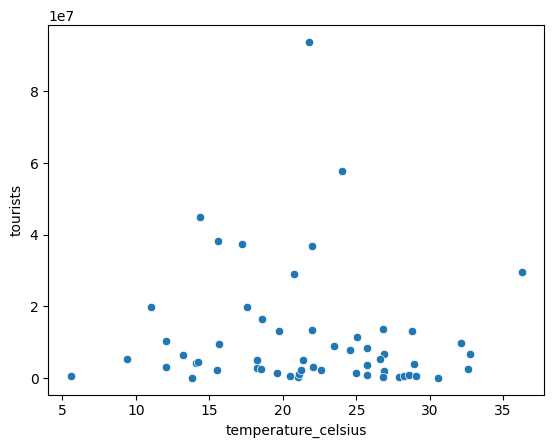

In [258]:
#sanity check
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="temperature_celsius", y= "tourists")
plt.show()

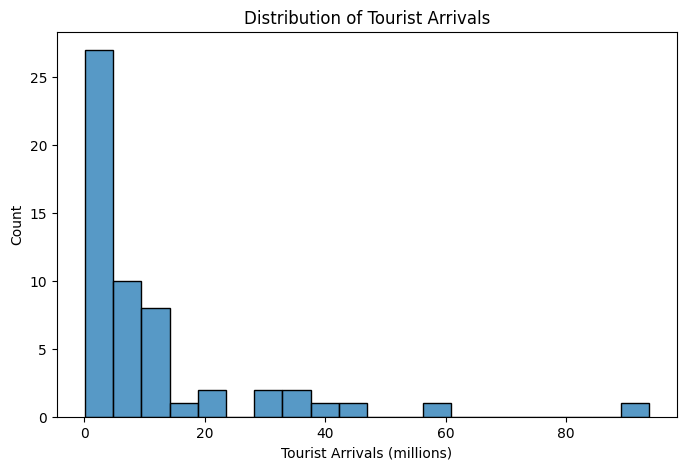

In [259]:
plt.figure(figsize=(8, 5))
sns.histplot(df["tourists"] / 1e6, bins=20)
plt.title("Distribution of Tourist Arrivals")
plt.xlabel("Tourist Arrivals (millions)")
plt.show()

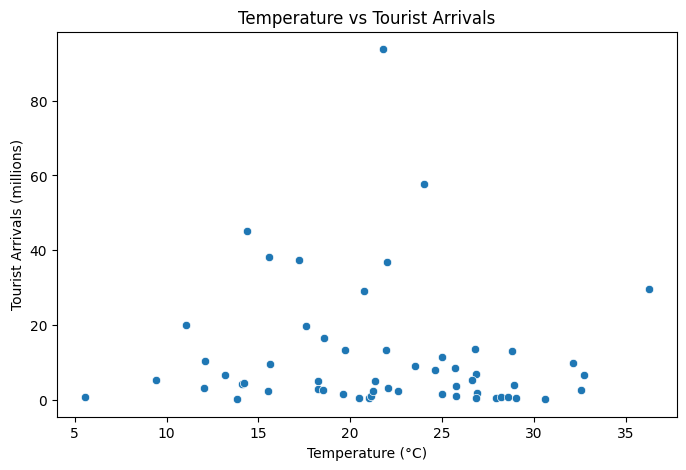

In [260]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="temperature_celsius", y=df["tourists"] / 1e6)
plt.title("Temperature vs Tourist Arrivals")
plt.xlabel("Temperature (°C)")
plt.ylabel("Tourist Arrivals (millions)")
plt.show()

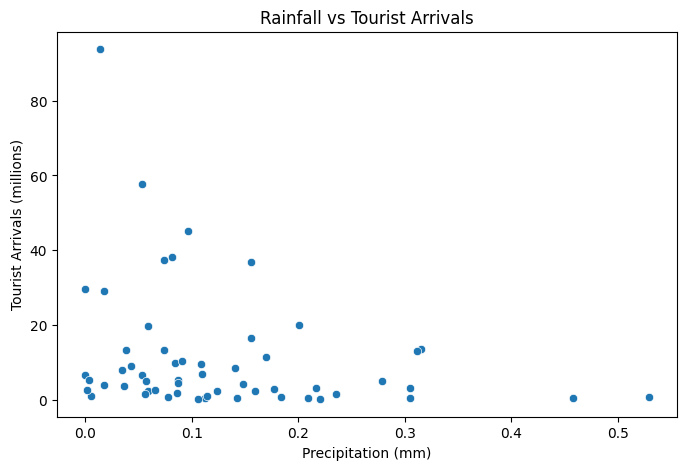

In [261]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="precip_mm", y=df["tourists"] / 1e6)
plt.title("Rainfall vs Tourist Arrivals")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Tourist Arrivals (millions)")
plt.show()

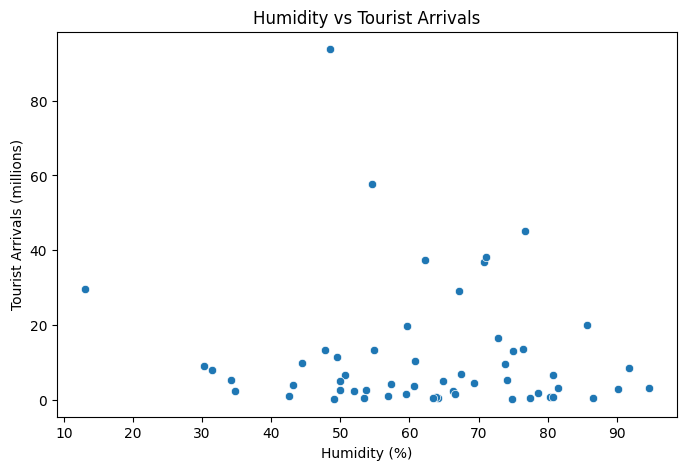

In [262]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="humidity", y=df["tourists"] / 1e6)
plt.title("Humidity vs Tourist Arrivals")
plt.xlabel("Humidity (%)")
plt.ylabel("Tourist Arrivals (millions)")
plt.show()

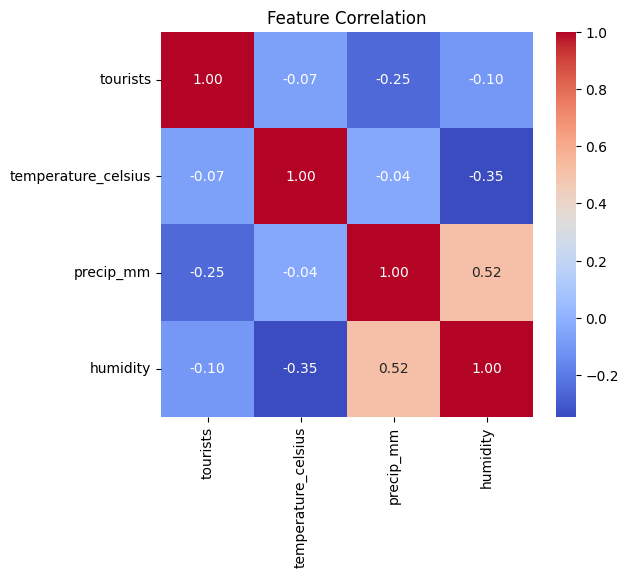

In [263]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df[["tourists","temperature_celsius","precip_mm","humidity"]].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation")
plt.show()

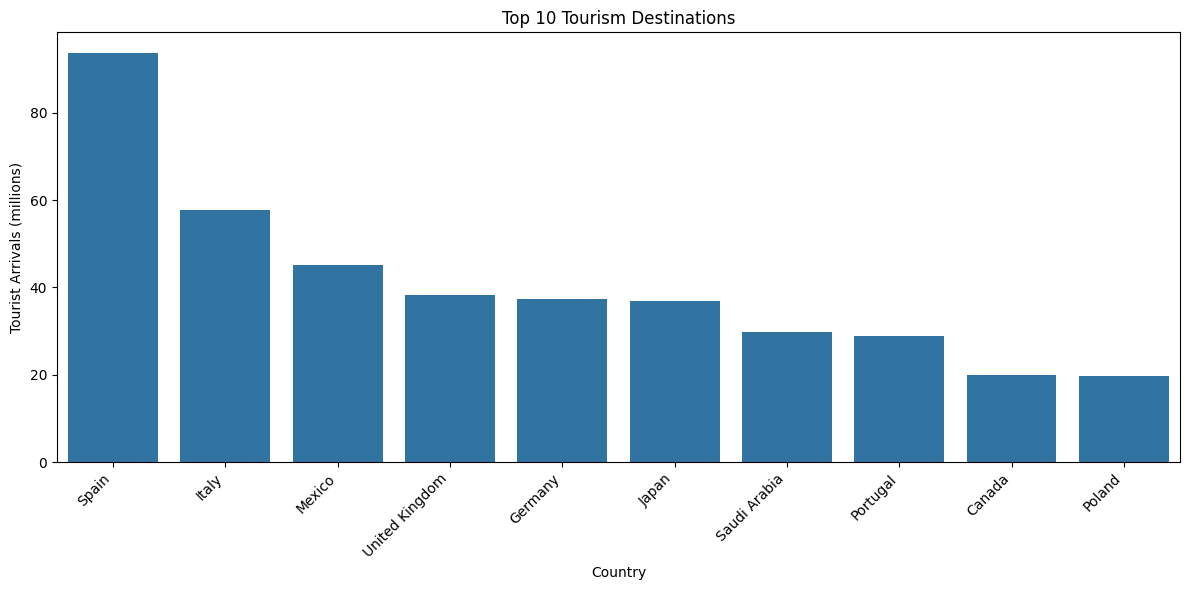

In [264]:
top = df.sort_values("tourists", ascending=False).head(10).copy()
top["tourists_m"] = top["tourists"] / 1e6

plt.figure(figsize=(12, 6))
sns.barplot(data=top, x="country", y="tourists_m")
plt.title("Top 10 Tourism Destinations")
plt.xlabel("Country")
plt.ylabel("Tourist Arrivals (millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### EDA Findings

- Tourist arrivals are **heavily right-skewed** — a small number of countries (France, Spain, the US) receive orders of magnitude more visitors than most.
- **No clear linear relationship** is visible between any individual weather variable and tourist volume. The scatter plots show wide, structureless clouds of points.
- The correlation heatmap confirms that temperature, precipitation, and humidity all have **weak correlations** with tourist arrivals.

This pattern strongly suggests that weather alone is insufficient to explain tourist demand. Destination-specific factors — geography, infrastructure, reputation, visa policy — likely play a far larger role.

> **Note:** SHAP values in Section 3 provide a model-based confirmation of these observations. By decomposing each prediction into per-feature contributions, SHAP shows the relative influence of temperature, precipitation, and humidity on the Random Forest's output — and whether any single weather feature carries meaningful signal once the model has been fitted.

## 3. Predictive Modelling

We test three models — **Linear Regression**, **Random Forest**, and **Gradient Boosting** — to predict tourist arrivals from weather features.

The target is `log(tourists + 1)` (`log_tourists`). A log transformation is applied because tourist arrivals are heavily right-skewed; a handful of countries receive orders of magnitude more visitors than the rest. Log-transforming the target stabilises variance and prevents a few dominant countries from distorting the models. (It decreases the variance.)

Model's matrics: **R²** and **MSE**.

### Round 1 — Baseline (raw tourist counts)

A simple Random Forest on raw tourist arrivals using only three weather features. This acts as a sanity check — if weather had no signal at all, we would expect R² near zero or negative.

In [265]:
#Define Features and Target variables
df.columns
X = df[["temperature_celsius", "precip_mm", "humidity"]]
y = df["tourists"]

In [266]:
#train, test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 123
)

In [267]:
#1st model: RandomForest
from sklearn.ensemble import RandomForestRegressor

model1 = RandomForestRegressor(random_state = 123)
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

In [268]:
#Evaluation
from sklearn.metrics import mean_squared_error, r2_score

mse1 = mean_squared_error(y_test, y_pred)
r2_1 = r2_score(y_test, y_pred)

print("MSE:", mse1)
print("R²:", r2_1)

MSE: 398635721154208.2
R²: -0.13034758325681262


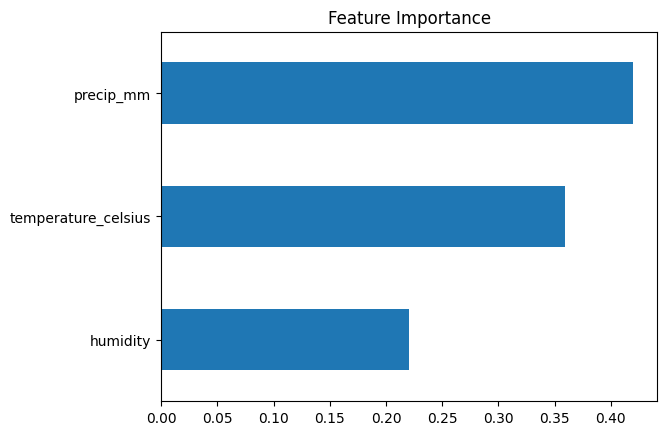

In [269]:
#Feature Importance
import pandas as pd
importance = pd.Series(
    model1.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

### Round 2 — Log-Transformed Target

The raw tourist counts are dominated by a few outlier countries. Applying `log1p` compresses this skew and makes the regression task more tractable. We compare all three model types on the transformed target.

In [270]:
#Redifine 
import numpy as np

df["log_tourists"] = np.log1p(df["tourists"])

X1 = df[["temperature_celsius", "precip_mm", "humidity"]]
y1 = df["log_tourists"]

from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=123
)

In [271]:
# Round 2 models — log_tourists target, weather features only
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123)
}

results1 = []

for name, model in models.items():
    model.fit(X1_train, y1_train)
    preds = model.predict(X1_test)

    rmse = np.sqrt(mean_squared_error(y1_test, preds))
    r2 = r2_score(y1_test, preds)

    results1.append({
        "Model": name,
        "RMSE (log scale)": round(rmse, 4),
        "R²": round(r2, 4)
    })

results1_df = pd.DataFrame(results1).sort_values("R²", ascending=False)
results1_df

,Model,RMSE (log scale),R²
1,Random Forest,1.8997,0.0592
0,Linear Regression,1.9118,0.0472
2,Gradient Boosting,2.2476,-0.3169


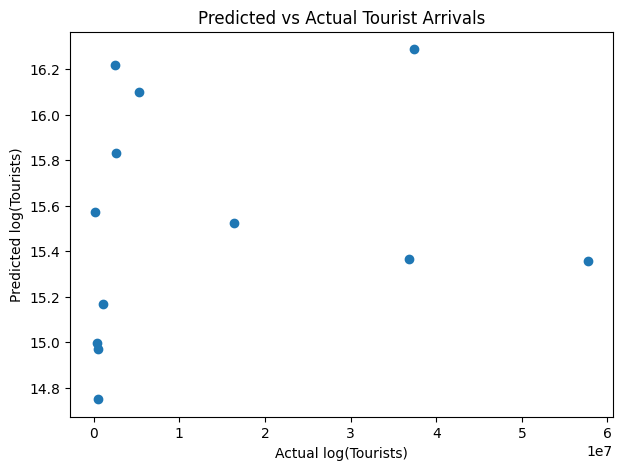

In [272]:
best_model1 = RandomForestRegressor(random_state=123)
best_model1.fit(X1_train, y1_train)
y_pred = best_model1.predict(X1_test)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual log(Tourists)")
plt.ylabel("Predicted log(Tourists)")
plt.title("Predicted vs Actual Tourist Arrivals")
plt.show()

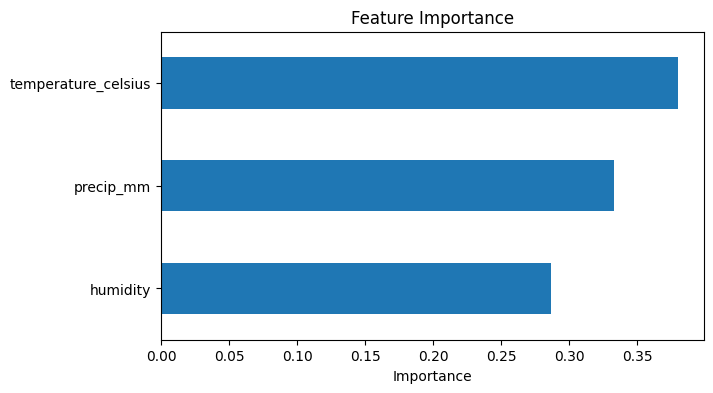

In [273]:
importance = pd.Series(
    best_model1.feature_importances_,
    index=X1.columns
).sort_values()

plt.figure(figsize=(7,4))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

### Round 3 — Feature Engineering + Country Dummies

We introduce a `climate_index` (temperature − 10 × precipitation) as a single composite weather signal, and add one-hot encoded country indicators. Country dummies allow the model to learn a country-specific intercept, effectively separating "country identity" from weather effects. If country dummies dominate feature importance, it suggests the model is relying on identity rather than climate.

In [274]:
# Round 3 — feature engineering + country dummies
df["climate_index"] = df["temperature_celsius"] - 10 * df["precip_mm"]
df_model = pd.get_dummies(df, columns=["country"], drop_first=True)

X2 = df_model.drop(columns=["tourists", "log_tourists", "Year"])
y2 = df_model["log_tourists"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=123
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123)
}

results2 = []

for name, model in models.items():
    model.fit(X2_train, y2_train)
    preds = model.predict(X2_test)

    rmse = np.sqrt(mean_squared_error(y2_test, preds))
    r2 = r2_score(y2_test, preds)

    results2.append({
        "Model": name,
        "RMSE (log scale)": round(rmse, 4),
        "R²": round(r2, 4)
    })

results2_df = pd.DataFrame(results2).sort_values("R²", ascending=False)
results2_df

,Model,RMSE (log scale),R²
1,Random Forest,1.9718,-0.0136
2,Gradient Boosting,2.0309,-0.0752
0,Linear Regression,2.3070,-0.3875


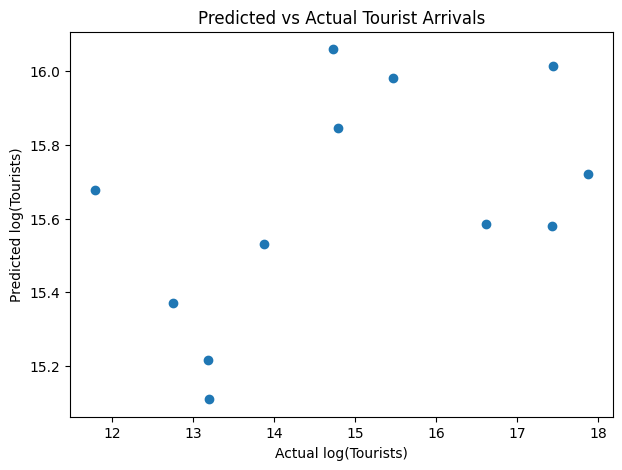

In [275]:
best_model2 = RandomForestRegressor(random_state=123)
best_model2.fit(X2_train, y2_train)
y_pred = best_model2.predict(X2_test)

plt.figure(figsize=(7,5))
plt.scatter(y2_test, y_pred)
plt.xlabel("Actual log(Tourists)")
plt.ylabel("Predicted log(Tourists)")
plt.title("Predicted vs Actual Tourist Arrivals")
plt.show()

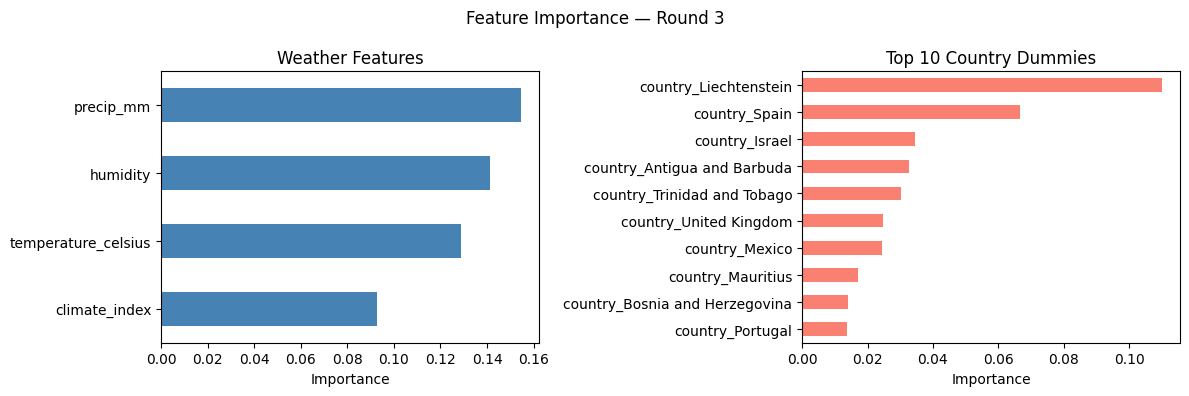


Total country dummies: 56
Dummies with zero importance: 13


In [276]:
importance = pd.Series(
    best_model2.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

# Split into weather/engineered features vs country dummies
weather_cols = ["temperature_celsius", "precip_mm", "humidity", "climate_index"]
weather_imp = importance[importance.index.isin(weather_cols)]
dummy_imp = importance[~importance.index.isin(weather_cols)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

weather_imp.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Weather Features")
axes[0].set_xlabel("Importance")

dummy_imp.head(10).sort_values().plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Top 10 Country Dummies")
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance — Round 3")
plt.tight_layout()
plt.show()

print(f"\nTotal country dummies: {len(dummy_imp)}")
print(f"Dummies with zero importance: {(dummy_imp == 0).sum()}")

In [277]:
# Cross-Validation (5-fold)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np
import pandas as pd

models_cv = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123)
}

cv_results = []
for name, model in models_cv.items():
    r2_scores = cross_val_score(model, X1, y1, cv=5, scoring="r2")
    rmse_scores = np.sqrt(-cross_val_score(model, X1, y1, cv=5, scoring="neg_mean_squared_error"))
    cv_results.append({
        "Model": name,
        "Mean CV RMSE": round(rmse_scores.mean(), 3),
        "Mean CV R²": round(r2_scores.mean(), 3),
        "Std CV R²": round(r2_scores.std(), 3)
    })

cv_df = pd.DataFrame(cv_results).sort_values("Mean CV R²", ascending=False)
cv_df

,Model,Mean CV RMSE,Mean CV R²,Std CV R²
0,Linear Regression,1.540,-0.139,0.256
1,Random Forest,1.698,-0.411,0.233
2,Gradient Boosting,1.914,-0.872,0.662


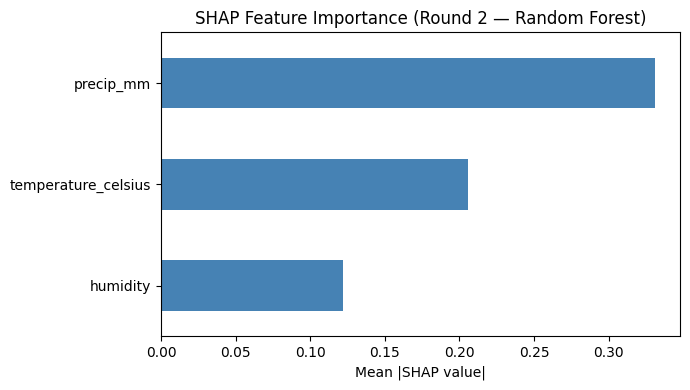

In [278]:
import shap
import numpy as np

# SHAP explains individual feature contributions for the Round 2 Random Forest.
# Mean absolute SHAP values indicate which features push predictions the most on average.
explainer = shap.TreeExplainer(best_model1)
shap_values = explainer.shap_values(X1_test)

mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X1_test.columns
).sort_values()

mean_shap.plot(kind="barh", figsize=(7, 4), color="steelblue")
plt.title("SHAP Feature Importance (Round 2 — Random Forest)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

## 4. Discussion & Conclusions

### Results Summary

All three model rounds produced R² values near zero or negative, across both hold-out evaluation and 5-fold cross-validation. This is itself the key finding: **weather conditions at the destination have little predictive power for tourist arrival volumes when considered in isolation.**

### Why Weather Alone Is Insufficient

Weather is not a strong predictor of tourist demand at the country level. Across all three modelling rounds, adding weather features produced no meaningful improvement in predictive performance. This suggests that **climate conditions are largely decorrelated from how many tourists a country receives** — people choose destinations for reasons that go well beyond temperature or rainfall.

Furthermore, travel decisions are typically made **months in advance**. By the time a tourist arrives at a destination, the booking was placed long before based on anticipated or seasonal expectations — not the actual weather at arrival. This means even accurate real-time weather data would not capture the true driver of demand.

Major factors not captured in this dataset include:

- **Country-level popularity** — the Eiffel Tower and the Great Wall attract visitors regardless of temperature
- **Economic and logistical factors** — visa policies, flight connectivity, accommodation infrastructure
- **Origin-country demand** — where tourists come *from* matters as much as where they go
- **Seasonality** — averaging weather across all snapshots masks peak-season patterns that actually drive travel decisions

### Data Limitations

- **Single year of weather data** — the Global Weather Repository only covers one year, while the tourism dataset spans multiple years. Every year of tourism data for a given country is therefore paired with the same weather values, making year-to-year variation in tourist arrivals impossible to explain through weather.
- Aggregating all weather readings to a single country-year mean discards regional and seasonal variation (This is huge.)
- The merged dataset after the inner join is relatively small, limiting model capacity

### Takeaway

Country identity — captured as one-hot dummies in Round 3 — dominated feature importance, confirming that destination-specific characteristics matter far more than climate alone. Weather may play a secondary role within a destination (e.g., seasonality within a country), but across countries it is not a reliable predictor of total tourist volumes.

Future work could incorporate economic indicators, seasonal weather breakdowns, and origin-country data to build a more complete picture.